In [1]:
from moviad.datasets.dataset_arguments import DatasetArguments
args = DatasetArguments(
        dataset_path = "/mnt/disk2/VAD_DATASETS/Medical/Medical",
        img_size = (256, 256),
        gt_mask_size = (256, 256),
        image_transform_list = None
    )

/home/ruslan/cl_medical/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os

os.listdir("/mnt/disk2/VAD_DATASETS/Medical/Medical")

['black_orange_capsule',
 'brain_tumor',
 'brain_tumor_brats2021',
 'Brain_White_Matter',
 'capsules',
 'coated_tablet',
 'Colon_Polyp',
 'embossed_tablet',
 'ginseng',
 'lettered_tablet',
 'Liver_Lesion',
 'liver_pathology',
 'liver_tumor',
 'magnesium',
 'ms_lesion',
 'Oblong_Pill',
 'oblong_tablet',
 'pill',
 'pink_matte_tablet',
 'pink_tablet',
 'red_tablet',
 'Round_Pill',
 'speckled_mint',
 'stroke_lesion',
 'Surgical_Mask',
 'white_marked_tablet',
 'white_tablet',
 'yellow_tablet']

In [3]:
to_keep = [
    "brain_tumor",
    "brain_tumor_brats2021",
    "Brain_White_Matter",
    "Colon_Polyp",
    "Liver_Lesion",
    "liver_pathology",
    "liver_tumor",
    "ms_lesion",
    "stroke_lesion"
    ]

In [4]:
from pathlib import Path

In [5]:
counts = {"train": {},
          "test": {}}

sets = ["train", "test"]

for s in sets:
    for category in to_keep:
        dir_counts = {}
        root = Path("/mnt/disk2/VAD_DATASETS/Medical/Medical") / category / s
        for cat in root.iterdir():
            dir_counts[cat.stem] = len(list(cat.iterdir()))
        counts[s].update({f"{category}": dir_counts})
    

In [6]:
counts

{'train': {'brain_tumor': {'good': 500},
  'brain_tumor_brats2021': {'good': 500},
  'Brain_White_Matter': {'good': 500},
  'Colon_Polyp': {'good': 500},
  'Liver_Lesion': {'good': 500},
  'liver_pathology': {'good': 500},
  'liver_tumor': {'good': 500},
  'ms_lesion': {'good': 500},
  'stroke_lesion': {'good': 500}},
 'test': {'brain_tumor': {'good': 100, 'tumor': 100},
  'brain_tumor_brats2021': {'good': 100, 'tumor': 100},
  'Brain_White_Matter': {'good': 100, 'wmh': 100},
  'Colon_Polyp': {'good': 100, 'polyps': 100},
  'Liver_Lesion': {'good': 100, 'liver': 100},
  'liver_pathology': {'disease': 100, 'good': 100},
  'liver_tumor': {'good': 100, 'tumor': 99},
  'ms_lesion': {'good': 100, 'ms_lesion': 99},
  'stroke_lesion': {'good': 100, 'stroke_lesion': 100}}}

In [7]:
counts_train = {}

for category in to_keep:
    root = Path("/mnt/disk2/VAD_DATASETS/Medical/Medical") / category / "train" / "good"
    counts = len(list(root.iterdir()))
    counts_train[category] = counts

In [8]:
counts_train

{'brain_tumor': 500,
 'brain_tumor_brats2021': 500,
 'Brain_White_Matter': 500,
 'Colon_Polyp': 500,
 'Liver_Lesion': 500,
 'liver_pathology': 500,
 'liver_tumor': 500,
 'ms_lesion': 500,
 'stroke_lesion': 500}

In [60]:
ratios = {cat: rat['good'] / sum(list(rat.values())) for cat, rat in counts.items()}

In [61]:
ratios

{'brain_tumor': 0.5,
 'brain_tumor_brats2021': 0.5,
 'Brain_White_Matter': 0.5,
 'Colon_Polyp': 0.5,
 'Liver_Lesion': 0.5,
 'liver_pathology': 0.5,
 'liver_tumor': 0.5025125628140703,
 'ms_lesion': 0.5025125628140703,
 'stroke_lesion': 0.5}

In [10]:
bmad_categories = os.listdir("/mnt/disk1/ruslan_nuriev/bmad/")
counts_bmad = {"train": {},
               "test": {},
               "valid": {}}

for s in ["train", "valid", "test"]:
    for category in bmad_categories:
        dir_counts = {}
        root = Path("/mnt/disk1/ruslan_nuriev/bmad") / category / s
        if s == "train":
            for cat in root.iterdir():
                dir_counts[cat.stem] = len(list((cat).iterdir()))
        else:
            for cat in root.iterdir():
                dir_counts[cat.stem] = len(list((cat / "img").iterdir()))
        counts_bmad[s].update({f"{category}": dir_counts})

In [11]:
counts_bmad

{'train': {'Brain_AD': {'good': 7500},
  'Chest_AD': {'good': 8000},
  'Histopathology_AD': {'good': 5088},
  'Liver_AD': {'good': 1542},
  'RetinaOCT2017_AD': {'good': 26315},
  'RetinaRESC_AD': {'good': 4297}},
 'test': {'Brain_AD': {'good': 640, 'ungood': 3075},
  'Chest_AD': {'good': 781, 'ungood': 16413},
  'Histopathology_AD': {'good': 1003, 'ungood': 994},
  'Liver_AD': {'good': 833, 'ungood': 660},
  'RetinaOCT2017_AD': {'good': 242, 'ungood': 726},
  'RetinaRESC_AD': {'good': 1041, 'ungood': 764}},
 'valid': {'Brain_AD': {'good': 39, 'ungood': 44},
  'Chest_AD': {'good': 70, 'ungood': 1420},
  'Histopathology_AD': {'good': 117, 'ungood': 119},
  'Liver_AD': {'good': 93, 'ungood': 73},
  'RetinaOCT2017_AD': {'good': 8, 'ungood': 24},
  'RetinaRESC_AD': {'good': 45, 'ungood': 70}}}

In [ ]:
os.listdir("")

In [12]:
counts_train_bmad = {}

for category in bmad_categories:
    root = Path("/mnt/disk1/ruslan_nuriev/bmad") / category / "train" / "good"
    counts = len(list(root.iterdir()))
    counts_train_bmad[category] = counts

In [13]:
counts_train_bmad

{'Brain_AD': 7500,
 'Chest_AD': 8000,
 'Histopathology_AD': 5088,
 'Liver_AD': 1542,
 'RetinaOCT2017_AD': 26315,
 'RetinaRESC_AD': 4297}

In [82]:
ratios_bmad = {cat: rat['good'] / sum(list(rat.values())) for cat, rat in counts_bmad.items()}

In [83]:
ratios_bmad

{'Brain_AD': 0.17227456258411844,
 'Chest_AD': 0.04542282191462138,
 'Histopathology_AD': 0.5022533800701051,
 'Liver_AD': 0.5579370395177495,
 'RetinaOCT2017_AD': 0.25,
 'RetinaRESC_AD': 0.5767313019390582}

In [95]:
adnet_brain = list((Path("/mnt/disk2/VAD_DATASETS/Medical/Medical") / "brain_tumor" / "test" / "good").iterdir())

In [96]:
bmad_brain = list((Path("/mnt/disk1/ruslan_nuriev/bmad") / "Brain_AD" / "test" / "good" / "img").iterdir())

In [101]:
adnet_brain = [directory.parts[-1] for directory in adnet_brain]

In [102]:
bmad_brain = [directory.parts[-1] for directory in bmad_brain]

In [104]:
counter = 0

for ad in adnet_brain:
    for bm in bmad_brain:
        if ad == bm:
            counter += 1

In [106]:
sorted(bmad_brain)

['00000_96.png',
 '00000_97.png',
 '00000_98.png',
 '00000_99.png',
 '00011_60.png',
 '00011_61.png',
 '00011_62.png',
 '00011_63.png',
 '00018_60.png',
 '00018_61.png',
 '00018_62.png',
 '00018_63.png',
 '00020_94.png',
 '00020_95.png',
 '00020_96.png',
 '00020_97.png',
 '00020_98.png',
 '00020_99.png',
 '00021_96.png',
 '00021_97.png',
 '00021_98.png',
 '00021_99.png',
 '00026_95.png',
 '00026_96.png',
 '00026_97.png',
 '00026_98.png',
 '00026_99.png',
 '00028_98.png',
 '00028_99.png',
 '00056_97.png',
 '00056_98.png',
 '00056_99.png',
 '00066_60.png',
 '00066_61.png',
 '00066_62.png',
 '00066_63.png',
 '00066_64.png',
 '00072_96.png',
 '00072_97.png',
 '00072_98.png',
 '00072_99.png',
 '00078_60.png',
 '00078_61.png',
 '00078_62.png',
 '00078_63.png',
 '00078_64.png',
 '00078_65.png',
 '00085_60.png',
 '00085_61.png',
 '00085_62.png',
 '00085_63.png',
 '00085_64.png',
 '00089_60.png',
 '00089_61.png',
 '00118_62.png',
 '00118_63.png',
 '00118_64.png',
 '00118_65.png',
 '00118_68.png

In [107]:
sorted(adnet_brain)

['00000_97.png',
 '00000_99.png',
 '00018_61.png',
 '00026_97.png',
 '00026_98.png',
 '00028_99.png',
 '00066_64.png',
 '00072_98.png',
 '00072_99.png',
 '00078_61.png',
 '00078_64.png',
 '00089_60.png',
 '00166_61.png',
 '00186_61.png',
 '00230_62.png',
 '00254_98.png',
 '00269_61.png',
 '00273_98.png',
 '00283_61.png',
 '00291_62.png',
 '00314_61.png',
 '00331_97.png',
 '00453_61.png',
 '00453_62.png',
 '00457_96.png',
 '00478_61.png',
 '00478_63.png',
 '00478_64.png',
 '00495_60.png',
 '00495_61.png',
 '00495_62.png',
 '00524_97.png',
 '00537_60.png',
 '00542_96.png',
 '00556_63.png',
 '00563_99.png',
 '00593_60.png',
 '00593_61.png',
 '00596_64.png',
 '00612_98.png',
 '00624_60.png',
 '00624_61.png',
 '00624_63.png',
 '00628_61.png',
 '00642_65.png',
 '00646_60.png',
 '00649_60.png',
 '00649_61.png',
 '00649_63.png',
 '00656_84.png',
 '00656_88.png',
 '00747_60.png',
 '00777_64.png',
 '00796_62.png',
 '00805_63.png',
 '01011_61.png',
 '01014_97.png',
 '01014_98.png',
 '01014_99.png

In [123]:
import matplotlib.pyplot as plt
import matplotlib.image as mpmg

img_adnet = mpmg.imread("/mnt/disk2/VAD_DATASETS/Medical/Medical/brain_tumor/test/good/00000_99.png")
img_bmad = mpmg.imread("/mnt/disk1/ruslan_nuriev/bmad/Brain_AD/test/good/img/00000_99.png")

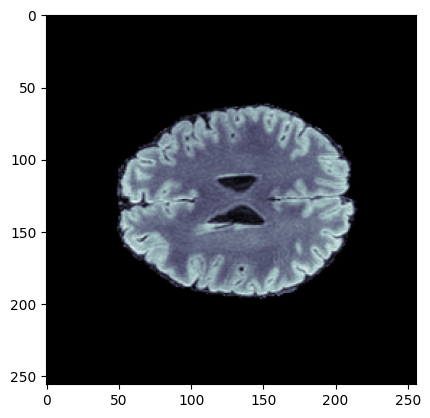

In [124]:
plt.imshow(img_adnet)

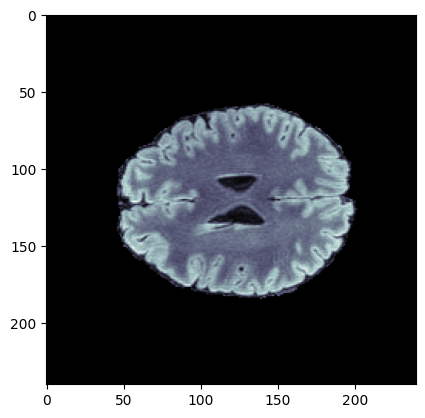

In [125]:
plt.imshow(img_bmad)

In [119]:
img_adnet.sum()

np.float32(26390.895)

In [118]:
img_bmad.sum()

np.float32(80777.41)

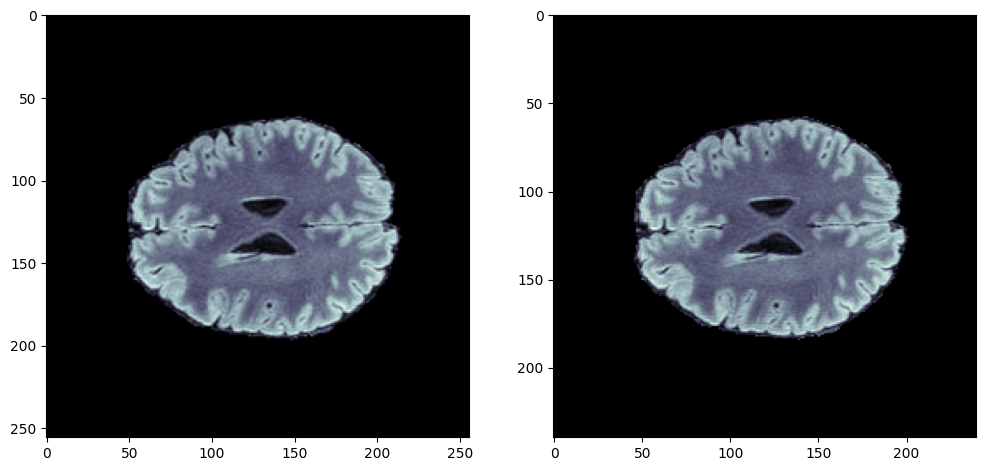

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_adnet, cmap='gray')
axes[1].imshow(img_bmad, cmap='gray')

In [14]:
list((Path("/mnt/disk2/VAD_DATASETS/Medical/Medical") / "brain_tumor_brats2021" / "test" / "good").iterdir())[:10]

[PosixPath('/mnt/disk2/VAD_DATASETS/Medical/Medical/brain_tumor_brats2021/test/good/BraTS2021_01469_flair_50.png'),
 PosixPath('/mnt/disk2/VAD_DATASETS/Medical/Medical/brain_tumor_brats2021/test/good/BraTS2021_01470_flair_56.png'),
 PosixPath('/mnt/disk2/VAD_DATASETS/Medical/Medical/brain_tumor_brats2021/test/good/BraTS2021_01470_flair_61.png'),
 PosixPath('/mnt/disk2/VAD_DATASETS/Medical/Medical/brain_tumor_brats2021/test/good/BraTS2021_01472_flair_33.png'),
 PosixPath('/mnt/disk2/VAD_DATASETS/Medical/Medical/brain_tumor_brats2021/test/good/BraTS2021_01472_flair_58.png'),
 PosixPath('/mnt/disk2/VAD_DATASETS/Medical/Medical/brain_tumor_brats2021/test/good/BraTS2021_01474_flair_60.png'),
 PosixPath('/mnt/disk2/VAD_DATASETS/Medical/Medical/brain_tumor_brats2021/test/good/BraTS2021_01474_flair_65.png'),
 PosixPath('/mnt/disk2/VAD_DATASETS/Medical/Medical/brain_tumor_brats2021/test/good/BraTS2021_01479_flair_5.png'),
 PosixPath('/mnt/disk2/VAD_DATASETS/Medical/Medical/brain_tumor_brats2021

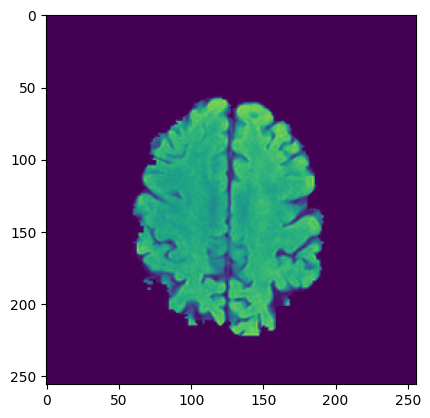

In [130]:
plt.imshow(mpmg.imread((Path("/mnt/disk2/VAD_DATASETS/Medical/Medical") / "brain_tumor_brats2021" / "test" / "good" / "BraTS2021_01509_flair_50.png")))

In [18]:
a = os.listdir("/mnt/disk1/ruslan_nuriev/bmad/Brain_AD/train/good")

In [19]:
b = os.listdir("/mnt/disk2/VAD_DATASETS/Medical/Medical/brain_tumor/train/good")

In [20]:
counter = 0

for ad in a:
    for bm in b:
        if ad == bm:
            counter += 1

In [ ]:
d = os.listdir("/mnt/disk1/ruslan_nuriev/bmad/Liver_AD/train/good")
c = os.listdir("/mnt/disk2/VAD_DATASETS/Medical/Medical/liver_pathology/train/good")

In [29]:
counter = 0

for ad in c:
    for bm in d:
        if ad == bm:
            counter += 1

In [30]:
counter

500

In [35]:
bm_test_liv = os.listdir("/mnt/disk1/ruslan_nuriev/bmad/Liver_AD/test/ungood/img")
ad_test_liv = os.listdir("/mnt/disk2/VAD_DATASETS/Medical/Medical/liver_pathology/test/disease")

In [36]:
counter = 0

for ad in ad_test_liv:
    for bm in bm_test_liv:
        if ad == bm:
            counter += 1

In [37]:
counter

94

In [38]:
bmad_categories

['Brain_AD',
 'Chest_AD',
 'Histopathology_AD',
 'Liver_AD',
 'RetinaOCT2017_AD',
 'RetinaRESC_AD']

In [39]:
to_keep

['brain_tumor',
 'brain_tumor_brats2021',
 'Brain_White_Matter',
 'Colon_Polyp',
 'Liver_Lesion',
 'liver_pathology',
 'liver_tumor',
 'ms_lesion',
 'stroke_lesion']

In [40]:
os.listdir("/mnt/disk2/VAD_DATASETS/Medical/Medical/Brain_White_Matter/test/good")

['case10_slice004.png',
 'case111_slice004.png',
 'case111_slice014.png',
 'case111_slice020.png',
 'case111_slice028.png',
 'case118_slice004.png',
 'case118_slice026.png',
 'case119_slice074.png',
 'case119_slice078.png',
 'case120_slice069.png',
 'case121_slice018.png',
 'case121_slice068.png',
 'case122_slice003.png',
 'case123_slice004.png',
 'case124_slice055.png',
 'case125_slice079.png',
 'case127_slice064.png',
 'case127_slice065.png',
 'case12_slice001.png',
 'case12_slice013.png',
 'case130_slice069.png',
 'case131_slice021.png',
 'case133_slice026.png',
 'case134_slice015.png',
 'case134_slice061.png',
 'case135_slice033.png',
 'case136_slice038.png',
 'case139_slice025.png',
 'case141_slice025.png',
 'case141_slice056.png',
 'case143_slice014.png',
 'case143_slice037.png',
 'case145_slice025.png',
 'case145_slice028.png',
 'case145_slice066.png',
 'case145_slice074.png',
 'case147_slice025.png',
 'case147_slice063.png',
 'case148_slice019.png',
 'case148_slice061.png',
 'c

In [ ]:
import pandas as pd

bmad_data =  {'train': {'Brain_AD': {'good': 7500}, 'Chest_AD': {'good': 8000}, 'Histopathology_AD': {'good': 5088}, 'Liver_AD': {'good': 1542}, 'RetinaOCT2017_AD': {'good': 26315}, 'RetinaRESC_AD': {'good': 4297}}, 'test': {'Brain_AD': {'good': 640, 'ungood': 3075}, 'Chest_AD': {'good': 781, 'ungood': 16413}, 'Histopathology_AD': {'good': 1003, 'ungood': 994}, 'Liver_AD': {'good': 833, 'ungood': 660}, 'RetinaOCT2017_AD': {'good': 242, 'ungood': 726}, 'RetinaRESC_AD': {'good': 1041, 'ungood': 764}}, 'valid': {'Brain_AD': {'good': 39, 'ungood': 44}, 'Chest_AD': {'good': 70, 'ungood': 1420}, 'Histopathology_AD': {'good': 117, 'ungood': 119}, 'Liver_AD': {'good': 93, 'ungood': 73}, 'RetinaOCT2017_AD': {'good': 8, 'ungood': 24}, 'RetinaRESC_AD': {'good': 45, 'ungood': 70}}}
adnet_data = {'train': {'brain_tumor': {'good': 500}, 'brain_tumor_brats2021': {'good': 500}, 'Brain_White_Matter': {'good': 500}, 'Colon_Polyp': {'good': 500}, 'Liver_Lesion': {'good': 500}, 'liver_pathology': {'good': 500}, 'liver_tumor': {'good': 500}, 'ms_lesion': {'good': 500}, 'stroke_lesion': {'good': 500}}, 'test': {'brain_tumor': {'good': 100, 'tumor': 100}, 'brain_tumor_brats2021': {'good': 100, 'tumor': 100}, 'Brain_White_Matter': {'good': 100, 'wmh': 100}, 'Colon_Polyp': {'good': 100, 'polyps': 100}, 'Liver_Lesion': {'good': 100, 'liver': 100}, 'liver_pathology': {'disease': 100, 'good': 100}, 'liver_tumor': {'good': 100, 'tumor': 99}, 'ms_lesion': {'good': 100, 'ms_lesion': 99}, 'stroke_lesion': {'good': 100, 'stroke_lesion': 100}}} 

rows = []

# BMAD
for domain, splits in bmad_data['train'].items():
    tr_g = splits['good']
    v_g, v_u = bmad_data['valid'][domain]['good'], bmad_data['valid'][domain]['ungood']
    te_g, te_u = bmad_data['test'][domain]['good'], bmad_data['test'][domain]['ungood']
    
    ratio = round(te_u / te_g, 2)
    rows.append(('BMAD', domain, tr_g, f"{v_g} / {v_u}", f"{te_g} / {te_u}", ratio))

# ADNet
for domain, splits in adnet_data['train'].items():
    tr_g = splits['good']
    
    # Grab the test dict, find the 'good' key, treat whatever the other key is as 'ungood'
    te_dict = adnet_data['test'][domain]
    te_g = te_dict.get('good', 0)
    te_u = sum(v for k, v in te_dict.items() if k != 'good')
    
    ratio = round(te_u / te_g, 2)
    rows.append(('ADNet', domain, tr_g, "—", f"{te_g} / {te_u}", ratio))

df = pd.DataFrame(rows, columns=['Dataset', 'Category', 'Train (G)', 'Val (G/U)', 'Test (G/U)', 'Test Ratio'])

# Print to Markdown:
# print(df.to_markdown(index=False))

# Or export to LaTeX for overleaf:
# print(df.to_latex(index=False, booktabs=True))

In [19]:
df

,Dataset,Category,Train (G),Val (G/U),Test (G/U),Test Ratio
0,BMAD,Brain_AD,7500,39 / 44,640 / 3075,4.80
1,BMAD,Chest_AD,8000,70 / 1420,781 / 16413,21.02
2,BMAD,Histopathology_AD,5088,117 / 119,1003 / 994,0.99
3,BMAD,Liver_AD,1542,93 / 73,833 / 660,0.79
4,BMAD,RetinaOCT2017_AD,26315,8 / 24,242 / 726,3.00
5,BMAD,RetinaRESC_AD,4297,45 / 70,1041 / 764,0.73
6,ADNet,brain_tumor,500,—,100 / 100,1.00
7,ADNet,brain_tumor_brats2021,500,—,100 / 100,1.00
8,ADNet,Brain_White_Matter,500,—,100 / 100,1.00
9,ADNet,Colon_Polyp,500,—,100 / 100,1.00


In [21]:
print(df.to_latex(index=False))

\begin{tabular}{llrllr}
\toprule
Dataset & Category & Train (G) & Val (G/U) & Test (G/U) & Test Ratio \\
\midrule
BMAD & Brain_AD & 7500 & 39 / 44 & 640 / 3075 & 4.800000 \\
BMAD & Chest_AD & 8000 & 70 / 1420 & 781 / 16413 & 21.020000 \\
BMAD & Histopathology_AD & 5088 & 117 / 119 & 1003 / 994 & 0.990000 \\
BMAD & Liver_AD & 1542 & 93 / 73 & 833 / 660 & 0.790000 \\
BMAD & RetinaOCT2017_AD & 26315 & 8 / 24 & 242 / 726 & 3.000000 \\
BMAD & RetinaRESC_AD & 4297 & 45 / 70 & 1041 / 764 & 0.730000 \\
ADNet & brain_tumor & 500 & — & 100 / 100 & 1.000000 \\
ADNet & brain_tumor_brats2021 & 500 & — & 100 / 100 & 1.000000 \\
ADNet & Brain_White_Matter & 500 & — & 100 / 100 & 1.000000 \\
ADNet & Colon_Polyp & 500 & — & 100 / 100 & 1.000000 \\
ADNet & Liver_Lesion & 500 & — & 100 / 100 & 1.000000 \\
ADNet & liver_pathology & 500 & — & 100 / 100 & 1.000000 \\
ADNet & liver_tumor & 500 & — & 100 / 99 & 0.990000 \\
ADNet & ms_lesion & 500 & — & 100 / 99 & 0.990000 \\
ADNet & stroke_lesion & 500 & — & 